In [21]:
%load_ext autoreload
%autoreload 2

import os
import sys
module_path = os.path.abspath(os.path.join('../..'))
if module_path not in sys.path:
    sys.path.append(module_path)

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd
import jax
import seaborn as sns

jax.config.update('jax_platforms', 'cpu')

plt.rcParams['font.family'] = 'Helvetica Light'

from behavioral_plotting import (
    plot_session,
    load_odor_site_df,
    plot_patch_statistics_per_session,
    plot_patch_statistics_across_dfs,
    plot_patch_statistics,
    plot_multi_df_accuracy_heatmap,
    plot_leave_probabilities,
    plot_stay_prob_distance_difference,
    append_index_phase,
    plot_grouped_mean_std,
    plot_stop_fraction,
    plot_first_patch_rewards_vs_other_prefactors,
    plot_rewards_by_patch_sequence,
    odor_colors,
)
from aux_funcs import format_plot, zero_pad
from nb_analysis_tools import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [22]:
# had to clear the font cache to get the Helvetica Light font to work.
# If you see a warning about missing fonts, run this cell and restart the kernel.

# import matplotlib as mpl
# import shutil, os

# # Find and delete the font cache
# cache_dir = mpl.get_cachedir()
# print(f"Cache dir: {cache_dir}")

# # Delete cache files
# for f in os.listdir(cache_dir):
#     if f.endswith('.json') or f.endswith('.cache'):
#         os.remove(os.path.join(cache_dir, f))
#         print(f"Deleted: {f}")

# print("Done — restart the kernel now")

In [49]:
GRU_INDEP_NETWORKS = [
    '../../../results/indep_exp_gru_offset_and_decay_d_test_30_envs/step_00/traj_000000.pkl',
]

GRU_INDEP_NETWORKS_MARKOV_TRAINED = [
    '../../../results/indep_exp_gru_offset_and_decay_markov/step_00/traj_000499.pkl',
    '../../../results/indep_exp_gru_offset_and_decay_markov/step_01/traj_000500.pkl',
]

GRU_INDEP_NETWORKS_MARKOV_TRAINED_V2 = [
    '../../../results/indep_exp_gru_offset_and_decay_markov_varied/step_00/traj_001999.pkl',
    '../../../results/indep_exp_gru_offset_and_decay_markov_varied/step_01/traj_002000.pkl',
]

GRU_INDEP_NETWORKS_MARKOV_TRAINED_V3 = [
    '../../../results/indep_exp_gru_offset_and_decay_markov_v2/step_00/traj_001999.pkl',
    '../../../results/indep_exp_gru_offset_and_decay_markov_v2_test/step_00/traj_000000.pkl',
]

## Behavioral traces

[0.  0.6 0.8]


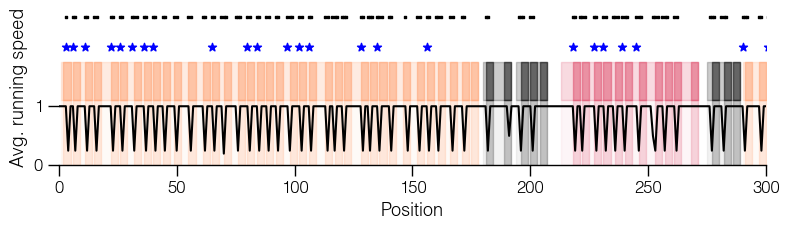

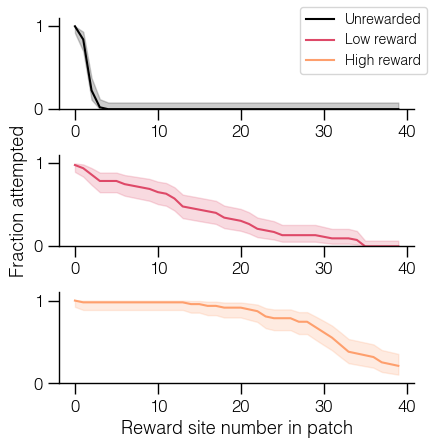

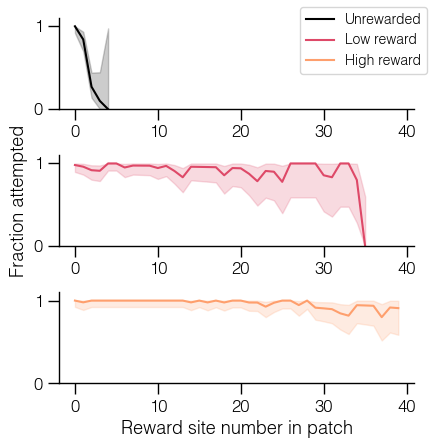

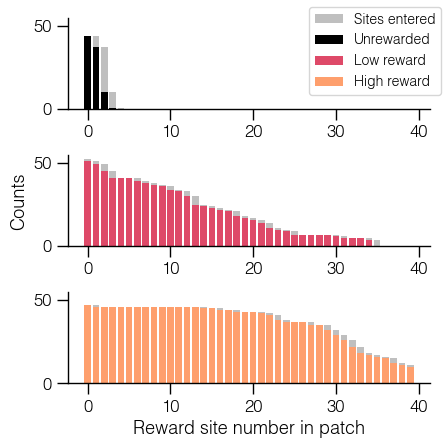

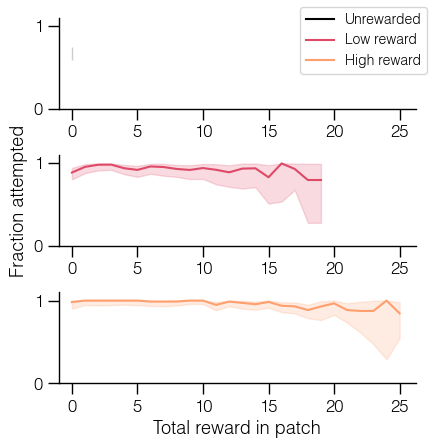

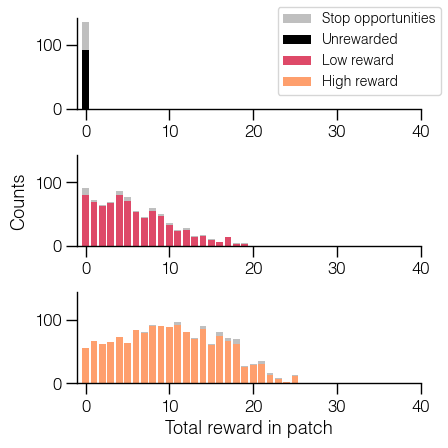

In [105]:
for i, data_path in enumerate(GRU_INDEP_NETWORKS[:1]):
    plot_session(
        data_path,
        session_idx=0,
        xlim=(0, 300),
        max_reward_param=40,
        max_reward_sites=30,
        use_fixed_colors=False,
        color_by_reward_param=False,
    )

[0.35322547 0.6152015  0.9934596 ]
[0.18884516 0.49933994 0.93150973]
[0.03541481 0.16426861 0.4986943 ]


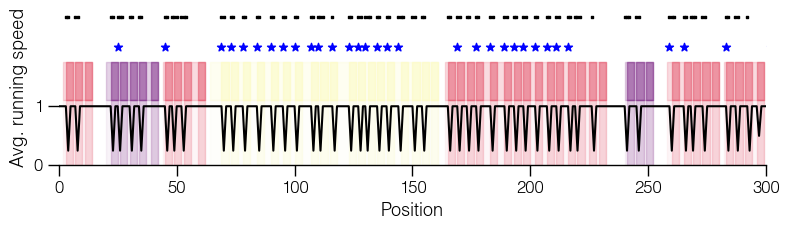

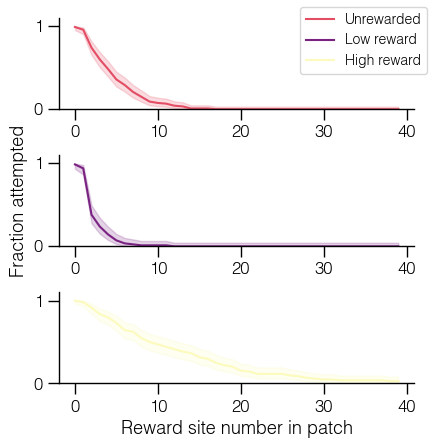

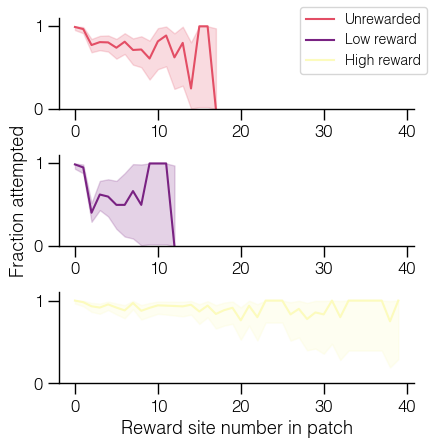

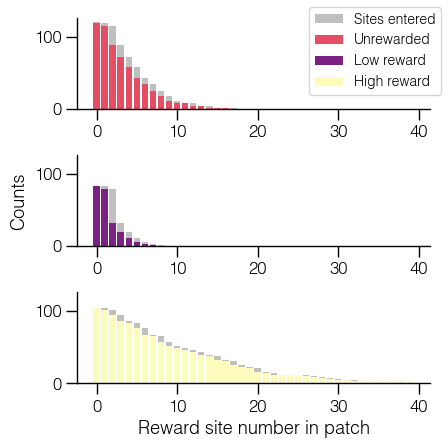

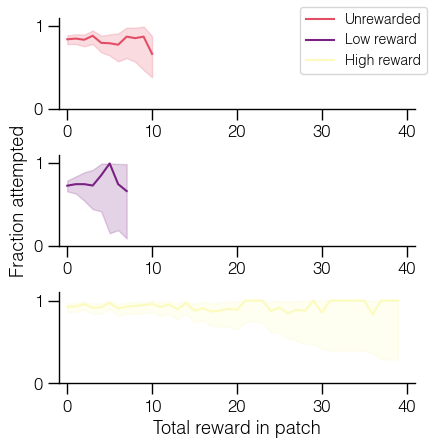

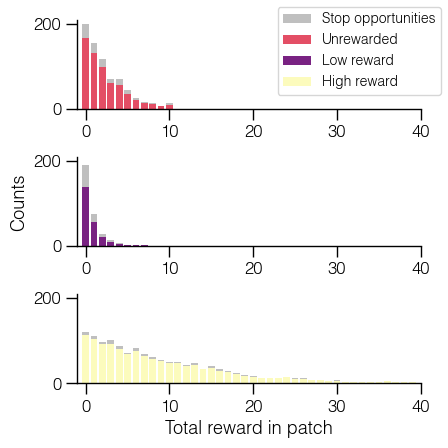

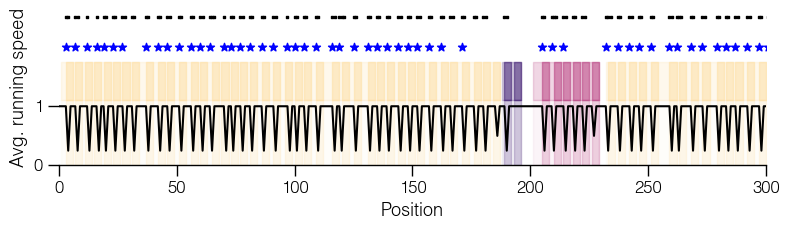

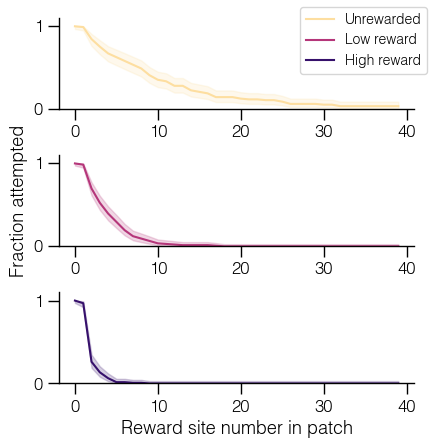

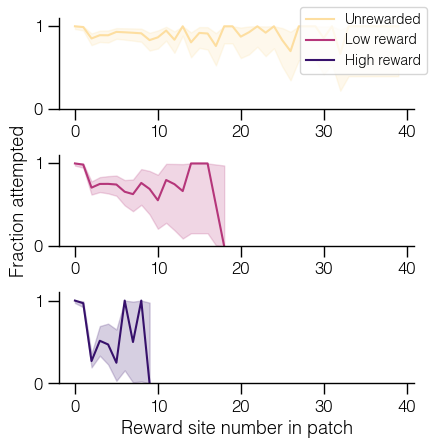

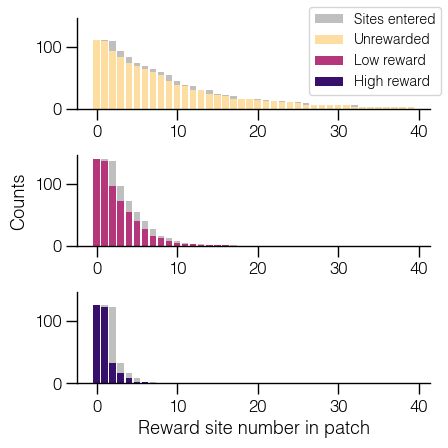

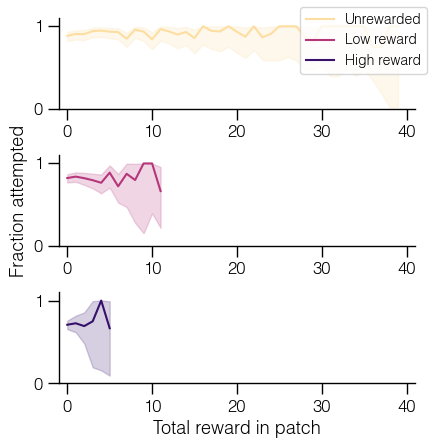

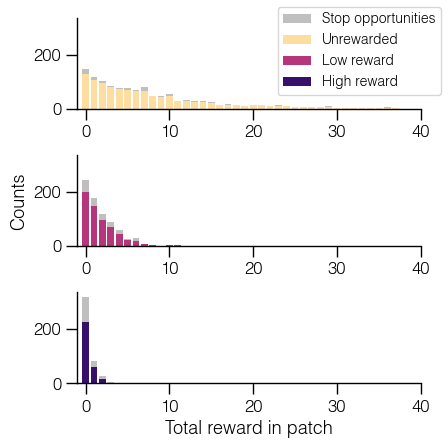

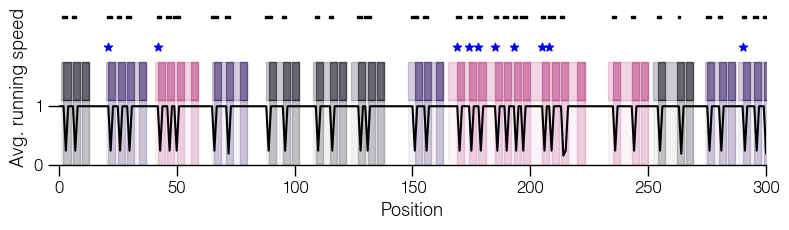

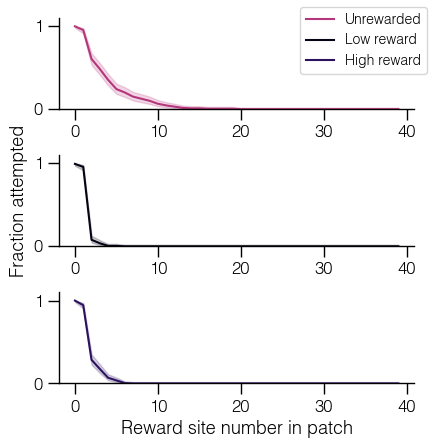

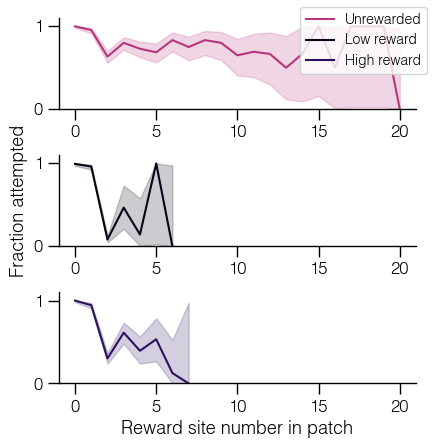

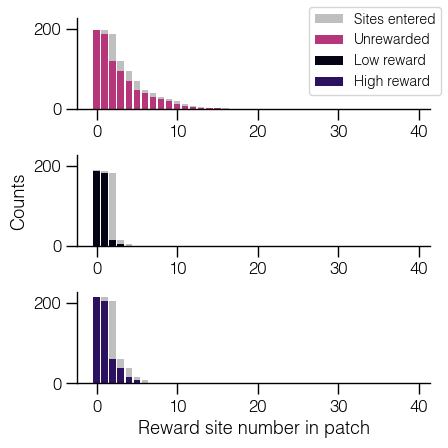

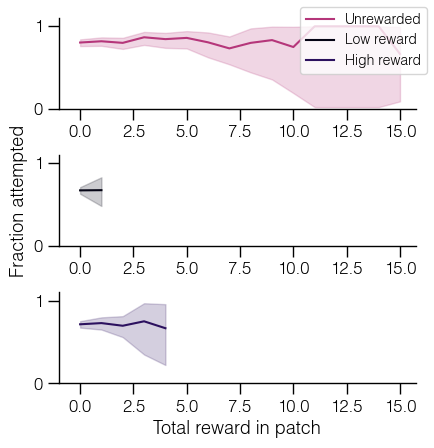

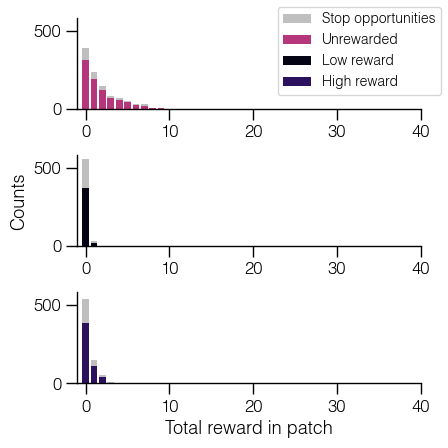

In [138]:
for i, data_path in enumerate(GRU_INDEP_NETWORKS_MARKOV_TRAINED[:1]):
    for i in range(3):
        plot_session(
            data_path,
            session_idx=i,
            xlim=(0, 300),
            max_reward_param=40,
            max_reward_sites=30,
            use_fixed_colors=False,
            color_by_reward_param=False,
        )

[0.  0.6 0.8]


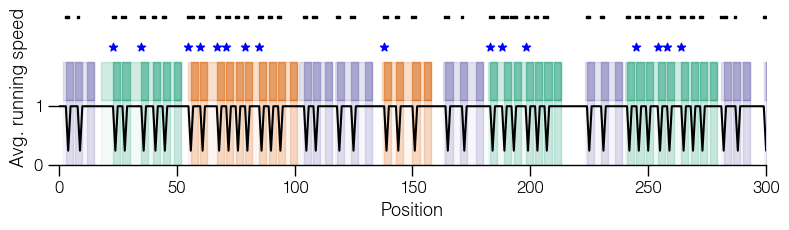

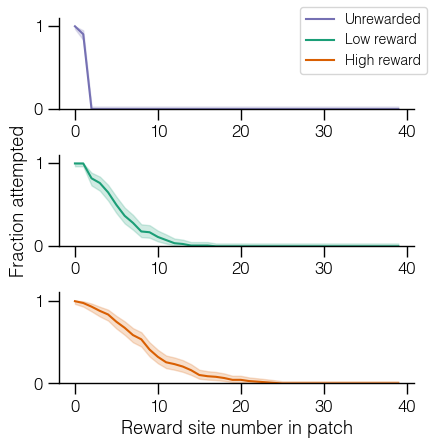

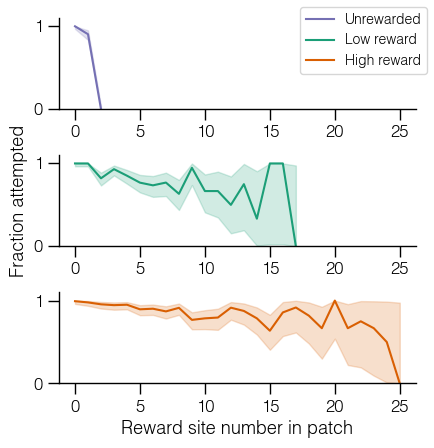

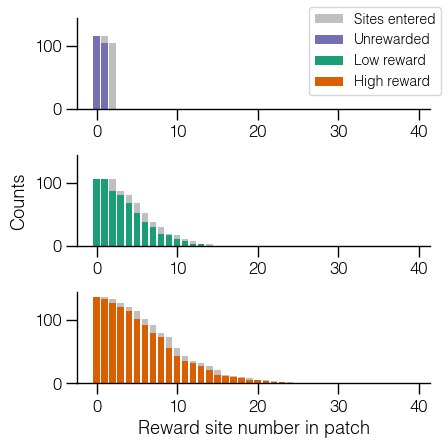

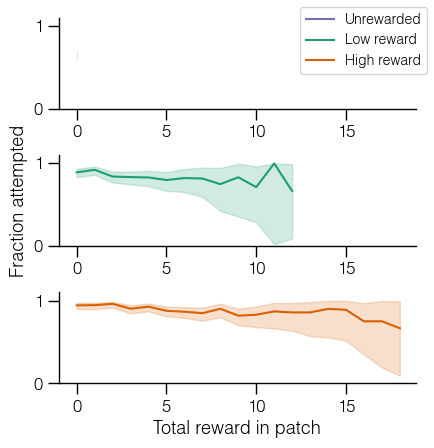

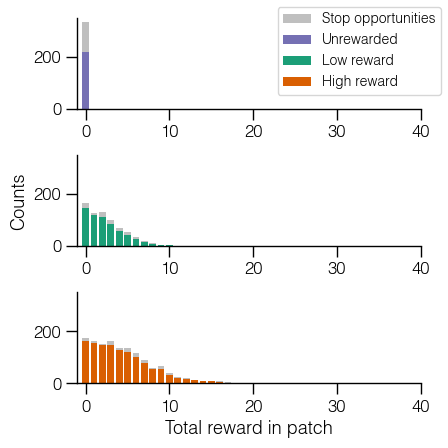

In [ ]:
for i, data_path in enumerate(GRU_INDEP_NETWORKS_MARKOV_TRAINED[1:]):
    plot_session(
        data_path,
        session_idx=0,
        xlim=(0, 300),
        max_reward_param=40,
        max_reward_sites=30,
        use_fixed_colors=True,
        color_by_reward_param=False,
    )

[0.03010092 0.6163379  0.67426586]
[0.11415539 0.2578864  0.3441986 ]
[0.03138485 0.734672   0.7558364 ]


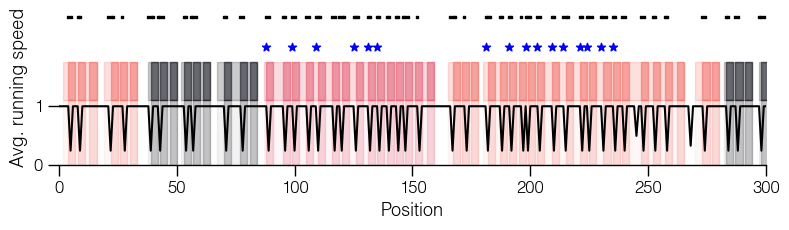

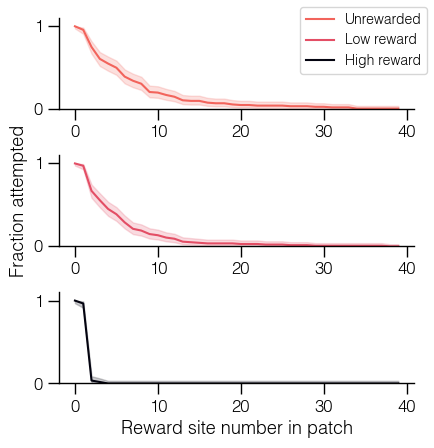

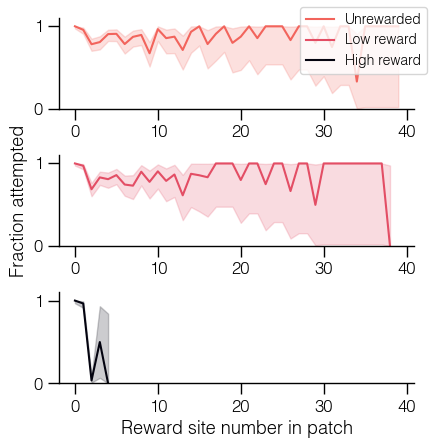

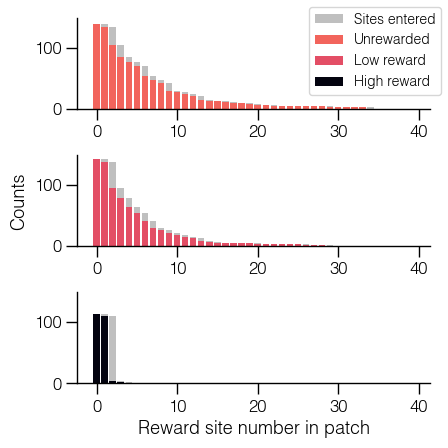

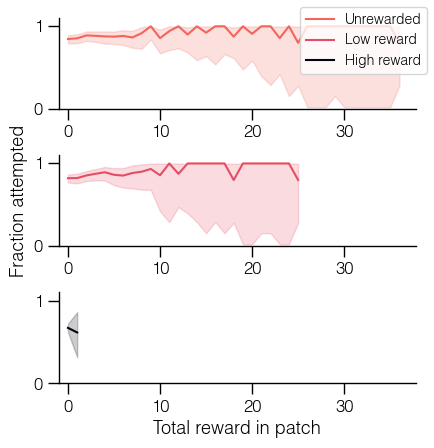

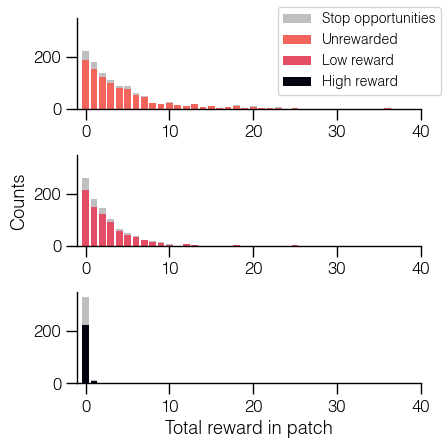

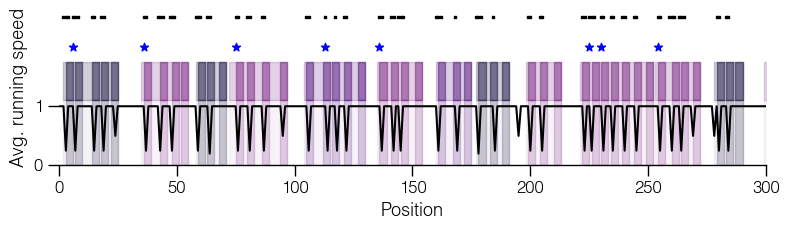

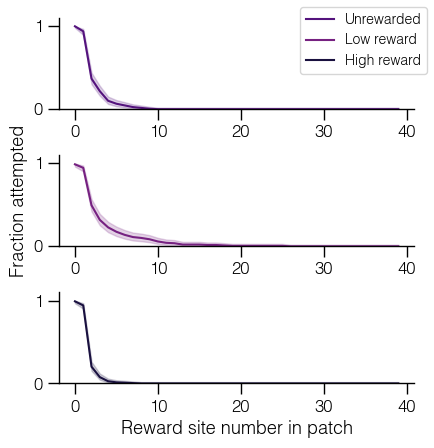

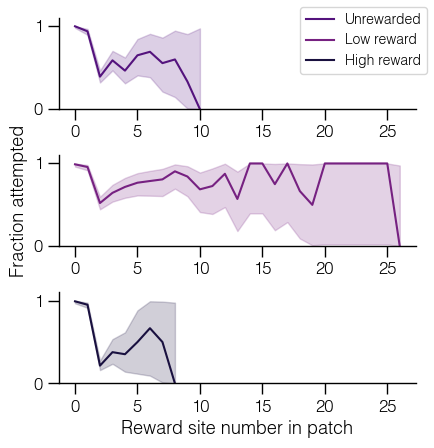

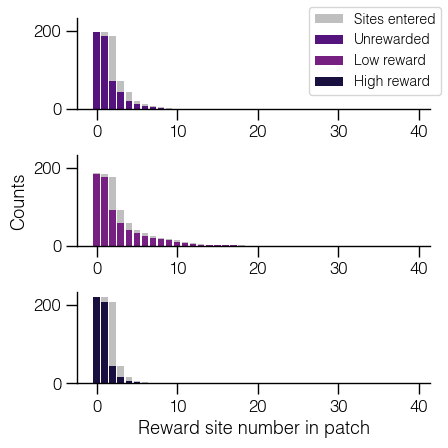

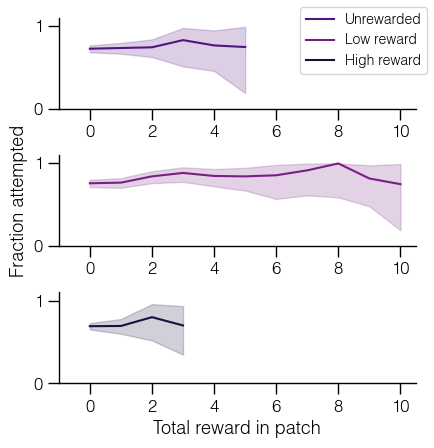

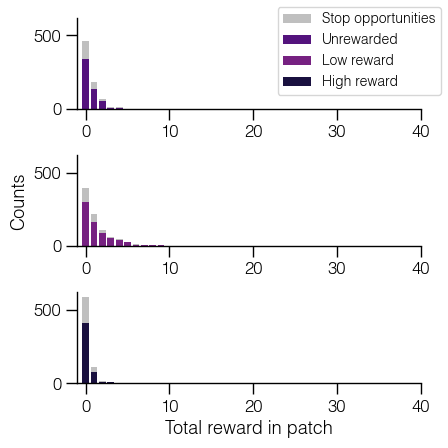

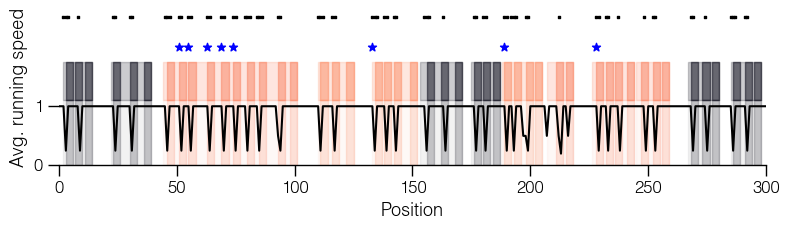

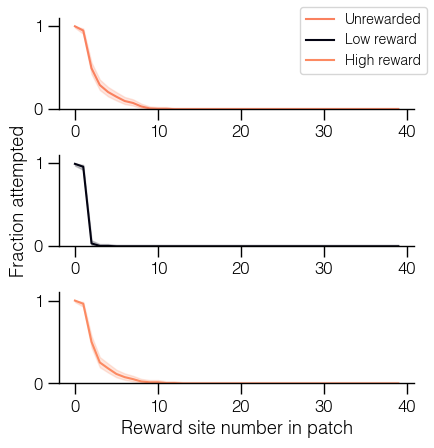

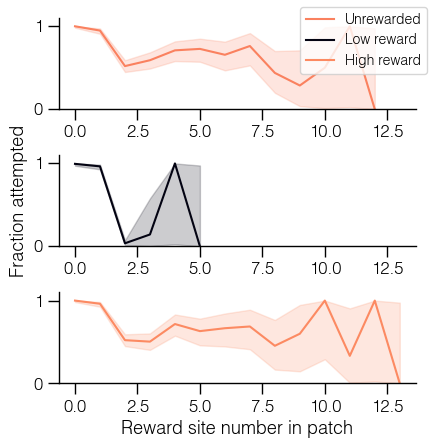

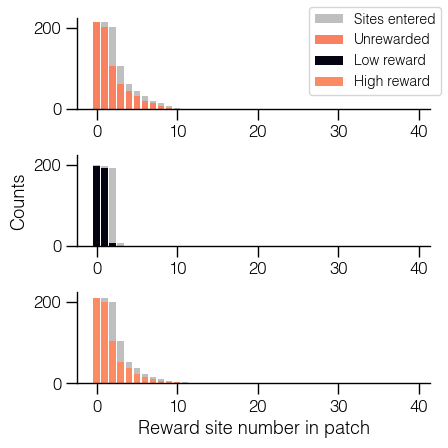

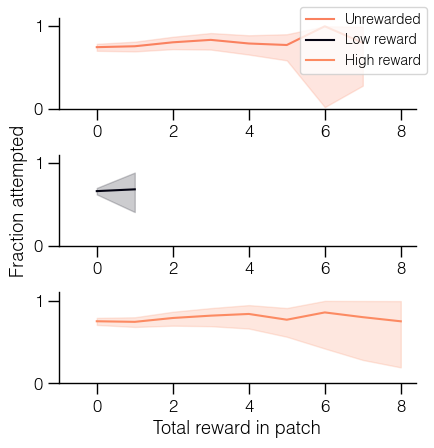

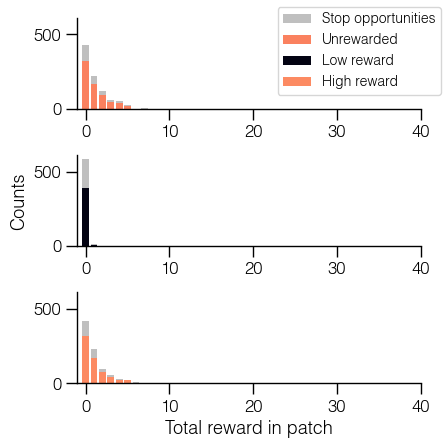

In [18]:
for i, data_path in enumerate(GRU_INDEP_NETWORKS_MARKOV_TRAINED_V2[:1]):
    for i in range(3):
        plot_session(
            data_path,
            session_idx=i,
            xlim=(0, 300),
            max_reward_param=40,
            max_reward_sites=30,
            use_fixed_colors=False,
            color_by_reward_param=False,
        )

[0.  0.6 0.8]
[0.  0.6 0.8]
[0.  0.6 0.8]


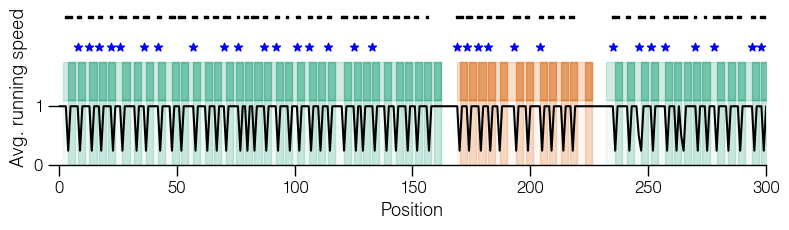

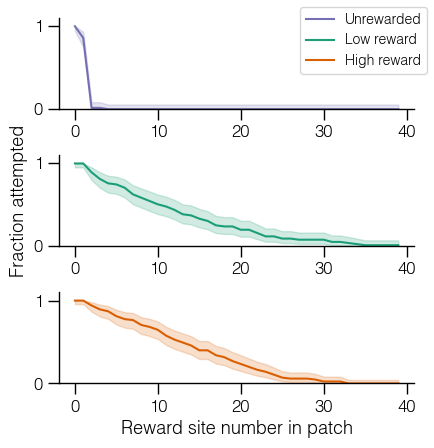

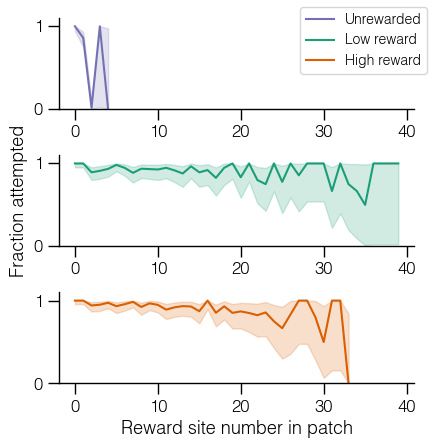

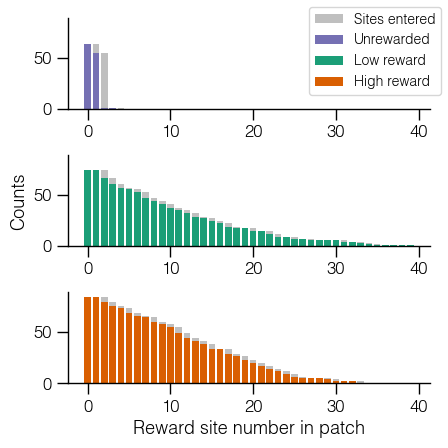

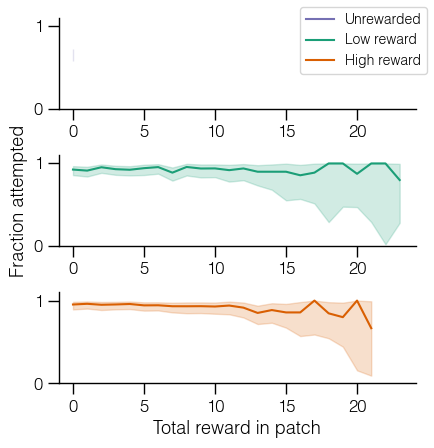

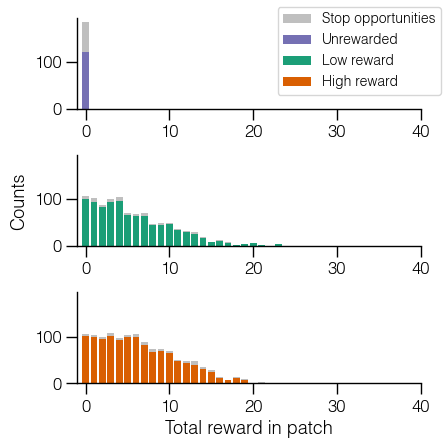

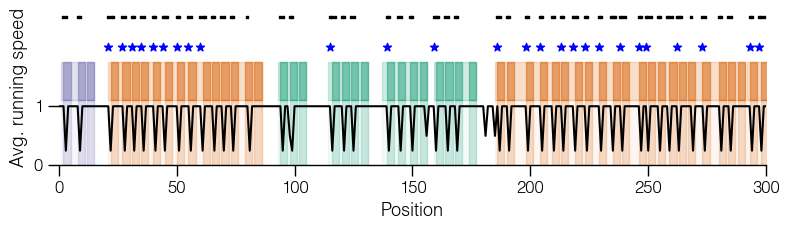

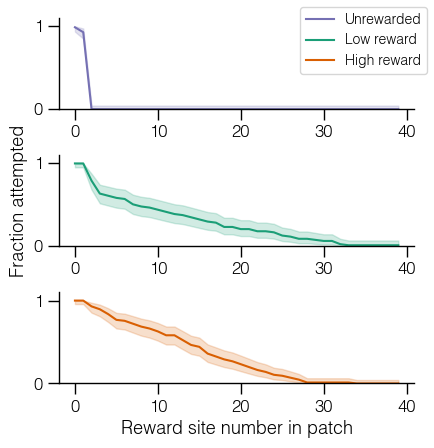

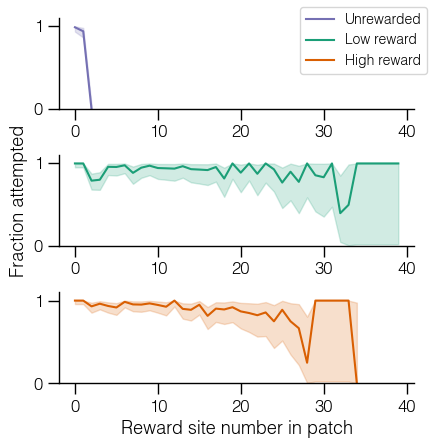

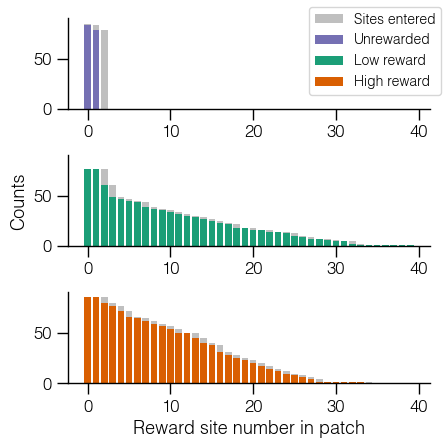

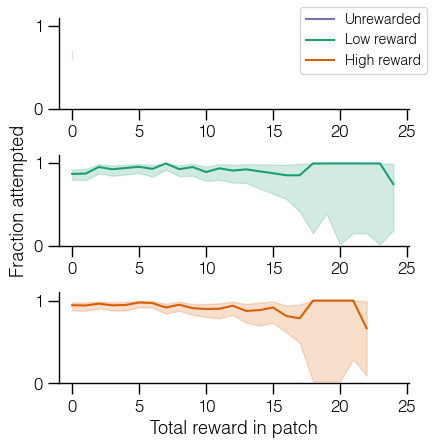

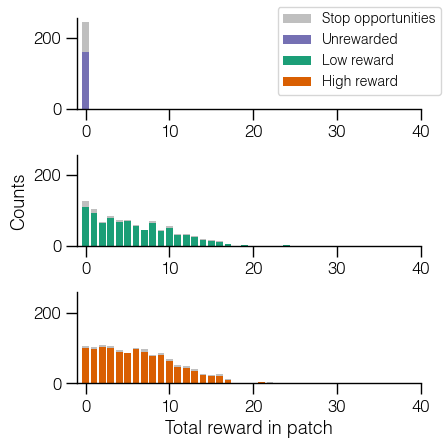

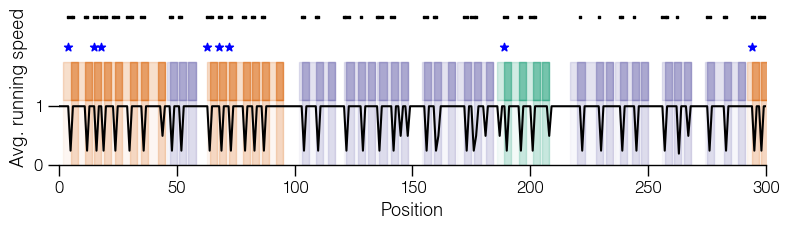

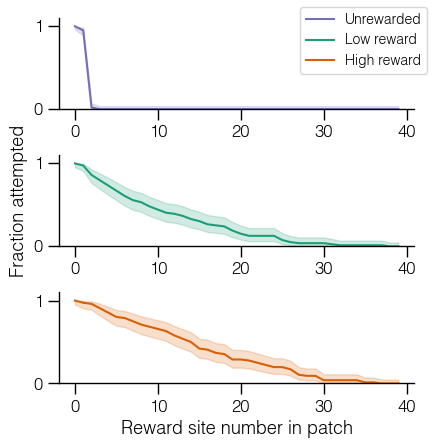

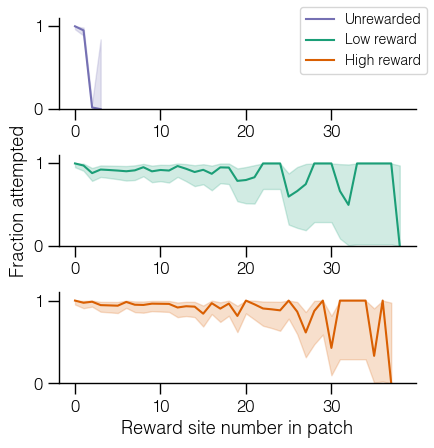

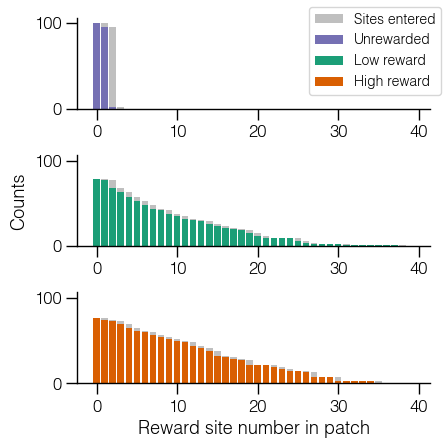

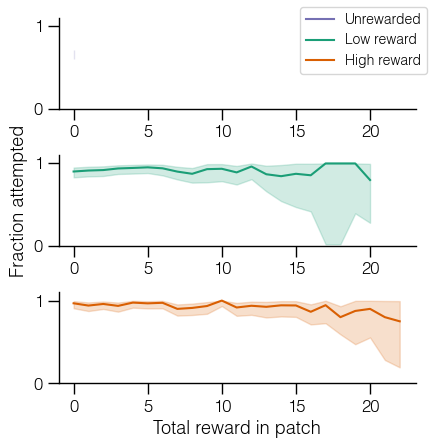

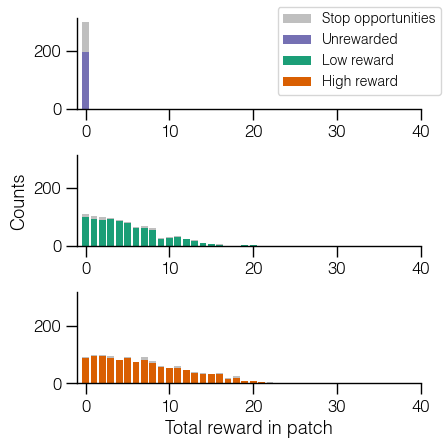

In [15]:
for i, data_path in enumerate(GRU_INDEP_NETWORKS_MARKOV_TRAINED_V2):
    for i in range(3):
        plot_session(
            data_path,
            session_idx=i,
            xlim=(0, 300),
            max_reward_param=40,
            max_reward_sites=30,
            use_fixed_colors=True,
            color_by_reward_param=False,
        )

## Odor site data loading

In [27]:
# network_paths = [
#     os.path.join(GRU_INDEP_NETWORKS, f'traj_{zero_pad(n, 6)}.pkl')
#     for n in session_indices
# ]

dfs = [
    load_odor_site_df(x, nn_num=nn_num)
    for nn_num, x in enumerate(GRU_INDEP_NETWORKS)
]

Session data loaded
Session summaries generated


In [139]:
dfs_markov_trained = [
    load_odor_site_df(x, nn_num=nn_num)
    for nn_num, x in enumerate(GRU_INDEP_NETWORKS_MARKOV_TRAINED)
]

Session data loaded
Session summaries generated
Session data loaded
Session summaries generated


In [6]:
dfs_markov_trained_v2 = [
    load_odor_site_df(x, nn_num=nn_num)
    for nn_num, x in enumerate(GRU_INDEP_NETWORKS_MARKOV_TRAINED_V2)
]

Session data loaded
Session summaries generated


In [51]:
dfs_markov_trained_v3 = [
    load_odor_site_df(x, nn_num=nn_num)
    for nn_num, x in enumerate(GRU_INDEP_NETWORKS_MARKOV_TRAINED_V3)
]

Session data loaded
Session summaries generated
Session data loaded
Session summaries generated


## Mean rewards harvested and probability of reward at leave across sessions

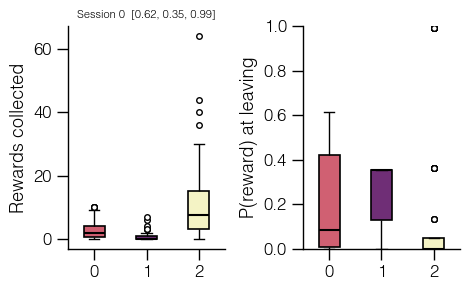

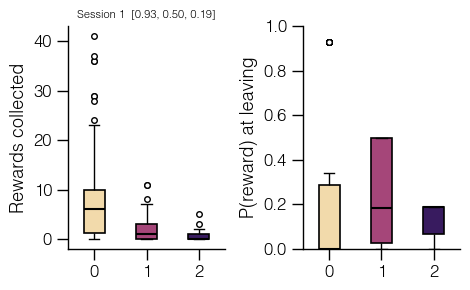

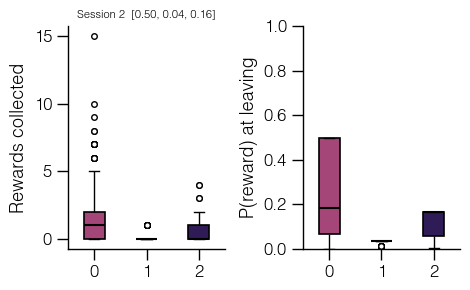

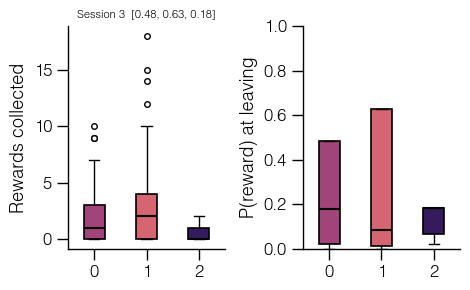

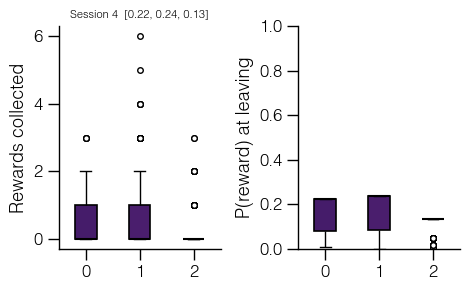

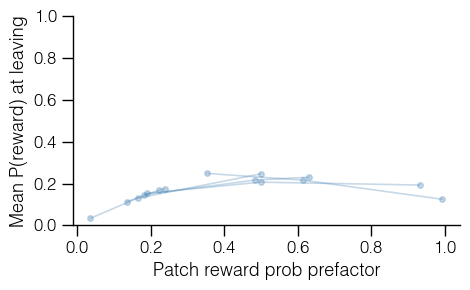

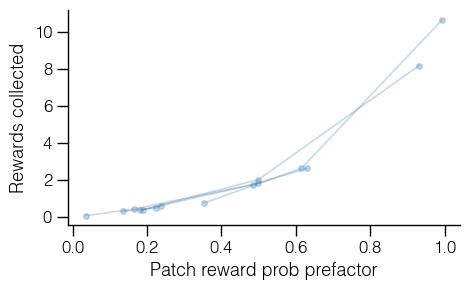

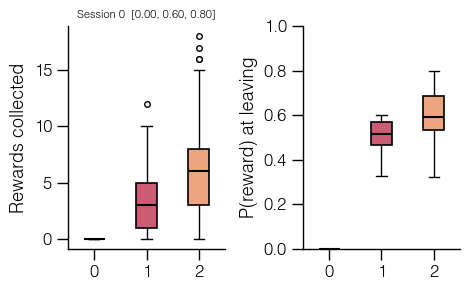

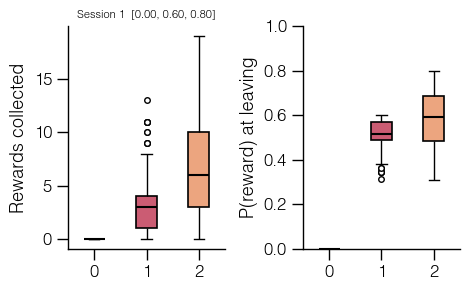

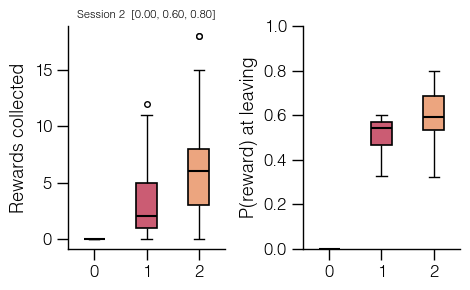

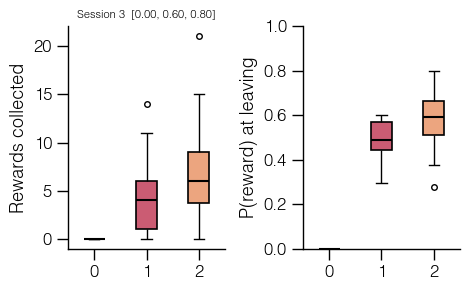

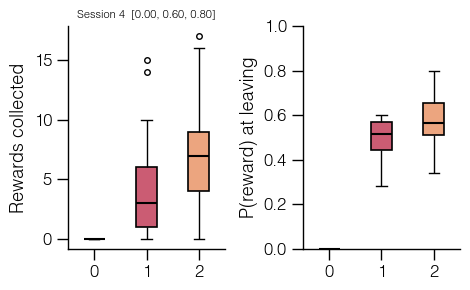

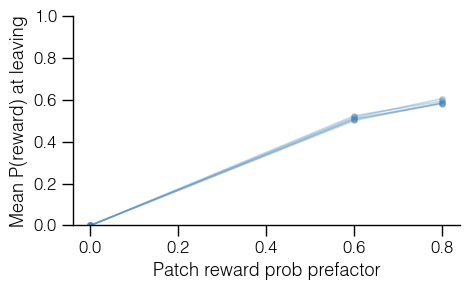

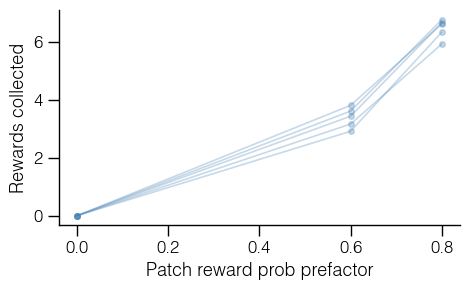

In [140]:
for df in dfs_markov_trained:
    plot_patch_statistics_per_session(
        df,
        ylim_right=[0, 1.],
    )

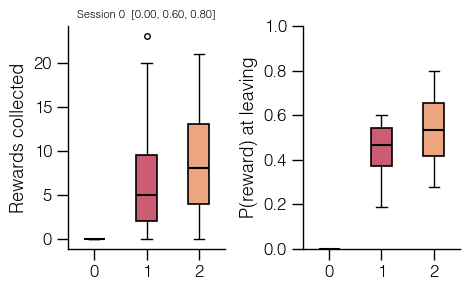

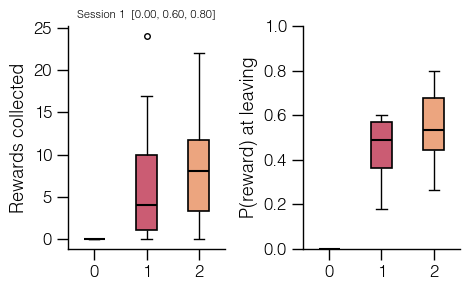

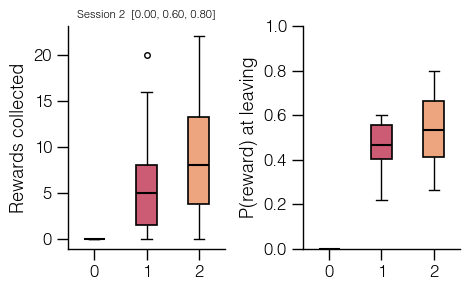

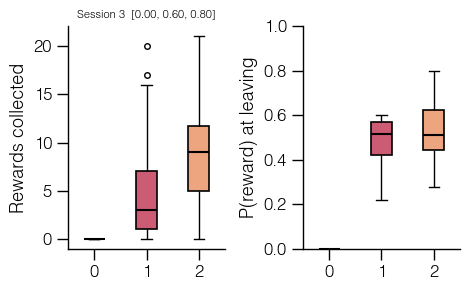

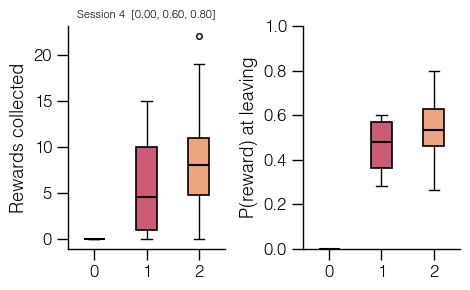

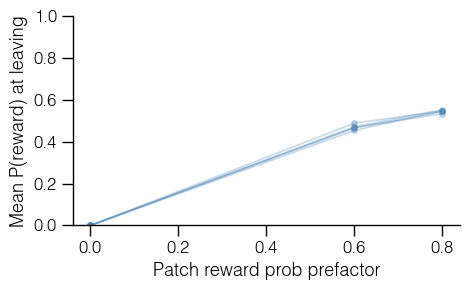

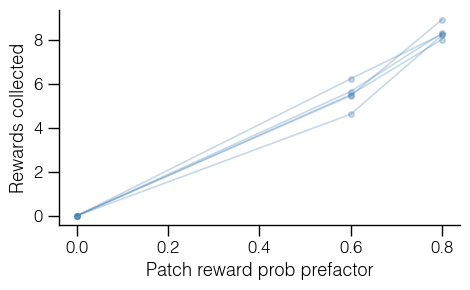

In [19]:
for df in dfs_markov_trained_v2:
    plot_patch_statistics_per_session(
        df,
        ylim_right=[0, 1.],
    )

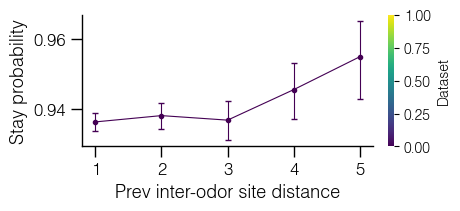

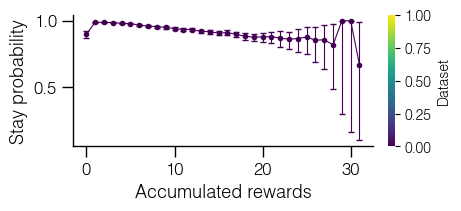

In [84]:
plot_leave_probabilities(
    [df[(df['index'] > 0) & (df['patch_type'] > 0)] for df in dfs],
    [
        'dist_last_odor_site',
    ],
    x_labels=[
        'Prev inter-odor site distance',
    ],
    cmap='viridis',
)

plot_leave_probabilities(
    [df[(df['index'] > 0) & (df['patch_type'] == 2)] for df in dfs],
    [
        'rewards_seen_in_patch',
    ],
    x_labels=[
        'Accumulated rewards',
    ],
    cmap='viridis',
)

Processing DF_0...


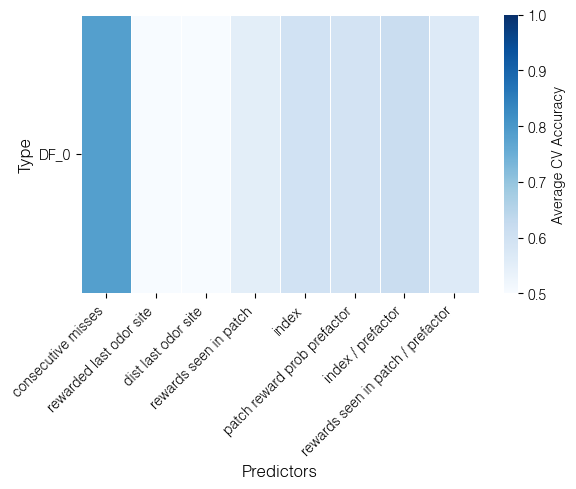

In [64]:
def gen_mask(df):
    return (df['index'] > 0) & (df['patch_type'] > 0)

plot_multi_df_accuracy_heatmap(
    [df[gen_mask(df)] for df in dfs],
    [
        'consecutive_misses',
        'rewarded_last_odor_site',
        'dist_last_odor_site',
        'rewards_seen_in_patch',
        'index',
        'patch_reward_prob_prefactor',
        'index / prefactor',
        'rewards_seen_in_patch / prefactor',
    ],
    # df_labels=['Randomized 499'] + [f'Fixed {s}' for s in np.arange(500, 600, 10)] + [f'Equal low {s}' for s in np.arange(600, 700, 10)],
    figsize=(6, 5),
)

Processing DF_0...


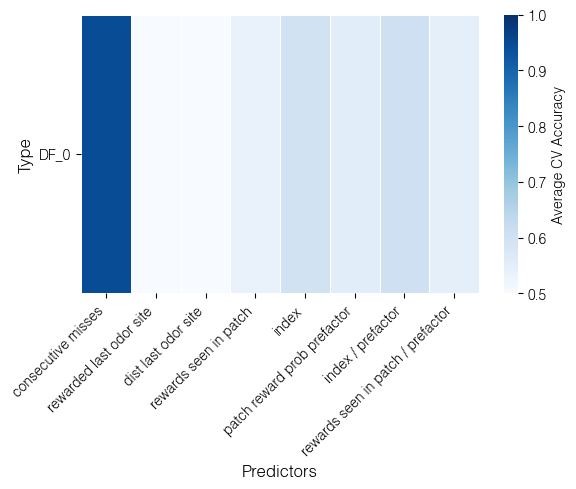

In [129]:
def gen_mask(df):
    return (df['index'] > 0) & (df['patch_type'] > 0)

plot_multi_df_accuracy_heatmap(
    [df[gen_mask(df)] for df in dfs_markov_trained],
    [
        'consecutive_misses',
        'rewarded_last_odor_site',
        'dist_last_odor_site',
        'rewards_seen_in_patch',
        'index',
        'patch_reward_prob_prefactor',
        'index / prefactor',
        'rewards_seen_in_patch / prefactor',
    ],
    # df_labels=['Randomized 499'] + [f'Fixed {s}' for s in np.arange(500, 600, 10)] + [f'Equal low {s}' for s in np.arange(600, 700, 10)],
    figsize=(6, 5),
)

## Accumulated reward against consecutive failures

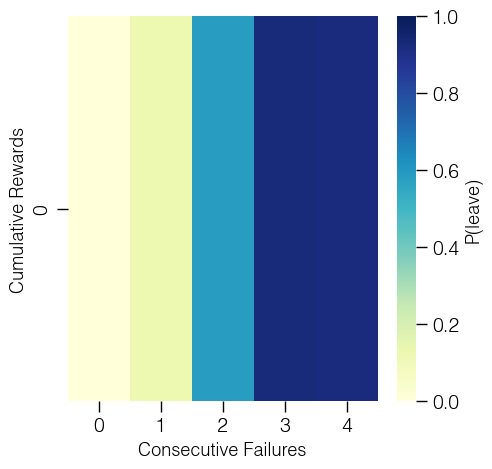

In [28]:
for df in dfs:
    plot_stop_fraction(
        df,
        'consecutive_misses',
        'rewards_seen_in_patch',
        invert_y=True,
        condition=lambda x: x[x['patch_type'] == 0],
        figsize=(5, 5),
        reverse=True,
        xlabel='Consecutive Failures',
        ylabel='Cumulative Rewards',
        min_n=20,
    )
None

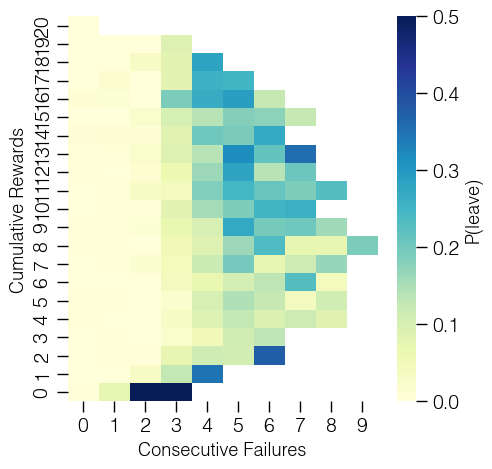

In [31]:
for df in dfs:
    plot_stop_fraction(
        df,
        'consecutive_misses',
        'rewards_seen_in_patch',
        invert_y=True,
        condition=lambda x: x[x['patch_type'] == 1],
        figsize=(5, 5),
        reverse=True,
        xlabel='Consecutive Failures',
        ylabel='Cumulative Rewards',
        min_n=20,
        vmin=0, vmax=0.5,
    )
None

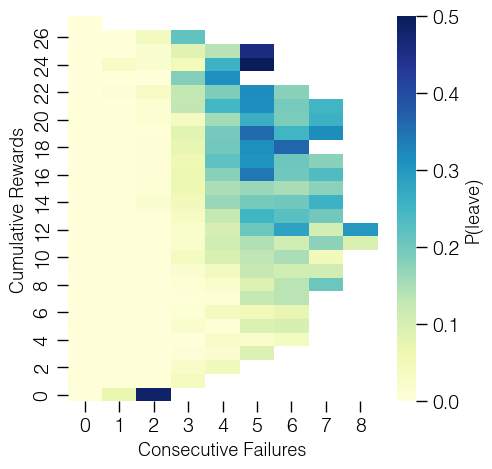

In [32]:
for df in dfs:
    plot_stop_fraction(
        df,
        'consecutive_misses',
        'rewards_seen_in_patch',
        invert_y=True,
        condition=lambda x: x[x['patch_type'] == 2],
        figsize=(5, 5),
        reverse=True,
        xlabel='Consecutive Failures',
        ylabel='Cumulative Rewards',
        min_n=20,
        vmin=0, vmax=0.5,
    )
None

In [ ]:
# for df in dfs[:1]:
#     plot_stop_fraction(
#         df,
#         'consecutive_misses',
#         'rewards_seen_in_patch',
#         invert_y=True,
#         figsize=(5, 5),
#         reverse=True,
#         xlabel='Consecutive Failures',
#         ylabel='Cumulative Rewards',
#         min_n=20,
#     )
# None

NameError: name 'dfs' is not defined

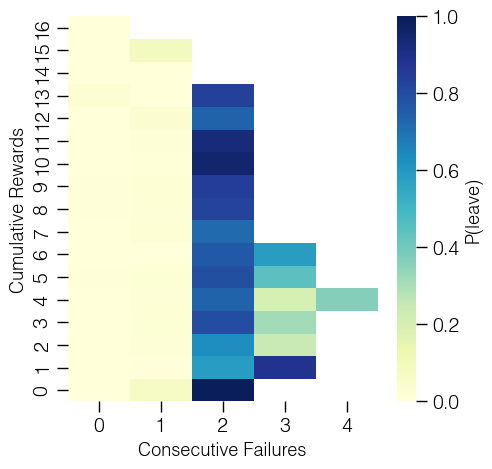

In [ ]:
for df in dfs_markov_trained[1:]:
    plot_stop_fraction(
        df,
        'consecutive_misses',
        'rewards_seen_in_patch',
        invert_y=True,
        condition=lambda x: x[x['patch_type'] == 1],
        figsize=(5, 5),
        reverse=True,
        xlabel='Consecutive Failures',
        ylabel='Cumulative Rewards',
        min_n=10,
    )
None

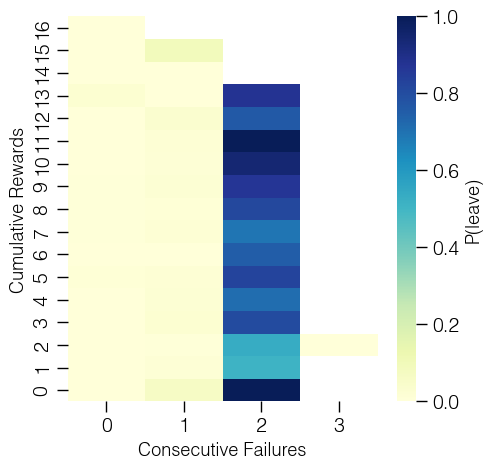

In [151]:
for df in dfs_markov_trained[1:]:
    plot_stop_fraction(
        df,
        'consecutive_misses',
        'rewards_seen_in_patch',
        invert_y=True,
        condition=lambda x: x[x['patch_type'] == 2],
        figsize=(5, 5),
        reverse=True,
        xlabel='Consecutive Failures',
        ylabel='Cumulative Rewards',
        min_n=10,
    )
None

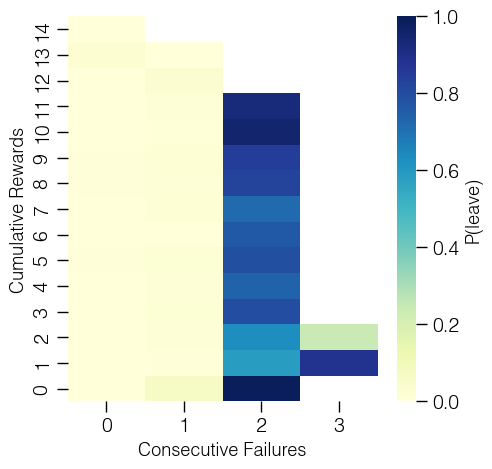

In [150]:
for df in dfs_markov_trained[1:]:
    plot_stop_fraction(
        df,
        'consecutive_misses',
        'rewards_seen_in_patch',
        invert_y=True,
        # condition=lambda x: x[x['patch_type'] == 2],
        figsize=(5, 5),
        reverse=True,
        xlabel='Consecutive Failures',
        ylabel='Cumulative Rewards',
        min_n=20,
    )
None

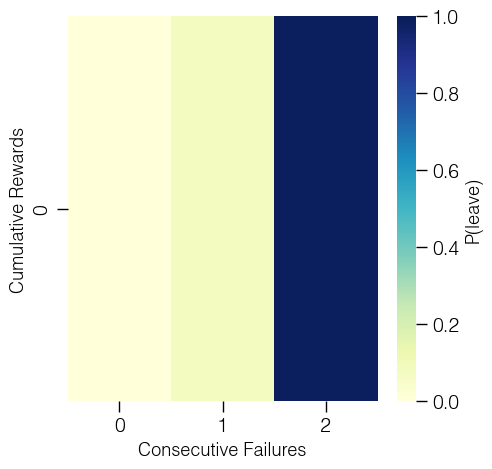

In [10]:
for df in dfs_markov_trained_v2:
    plot_stop_fraction(
        df,
        'consecutive_misses',
        'rewards_seen_in_patch',
        invert_y=True,
        condition=lambda x: x[x['patch_type'] == 0],
        figsize=(5, 5),
        reverse=True,
        xlabel='Consecutive Failures',
        ylabel='Cumulative Rewards',
        min_n=20,
    )
None

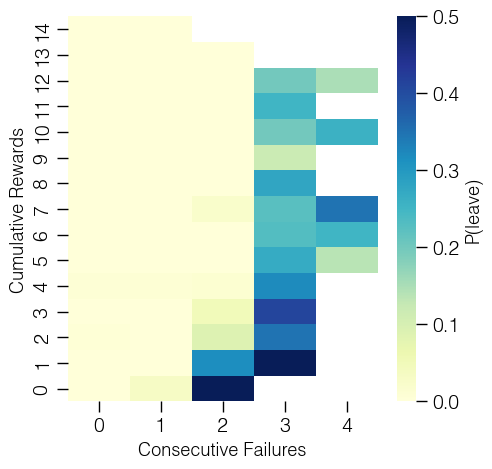

In [ ]:
for df in dfs_markov_trained_v2:
    plot_stop_fraction(
        df,
        'consecutive_misses',
        'rewards_seen_in_patch',
        invert_y=True,
        condition=lambda x: x[x['patch_type'] == 1],
        figsize=(5, 5),
        reverse=True,
        xlabel='Consecutive Failures',
        ylabel='Cumulative Rewards',
        min_n=20,
        vmin=0, vmax=0.5,
    )
None

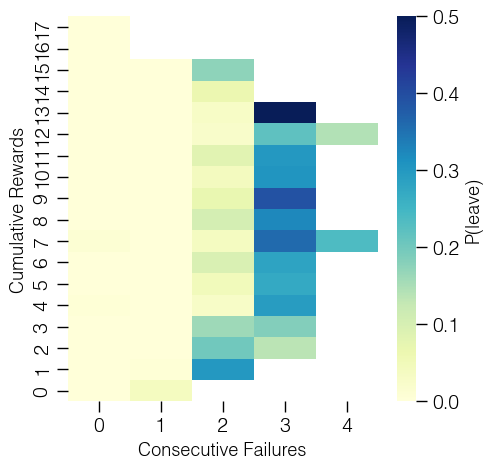

In [36]:
for df in dfs_markov_trained_v2:
    plot_stop_fraction(
        df,
        'consecutive_misses',
        'rewards_seen_in_patch',
        invert_y=True,
        condition=lambda x: x[x['patch_type'] == 2],
        figsize=(5, 5),
        reverse=True,
        xlabel='Consecutive Failures',
        ylabel='Cumulative Rewards',
        min_n=20,
        vmin=0, vmax=0.5,
    )
None

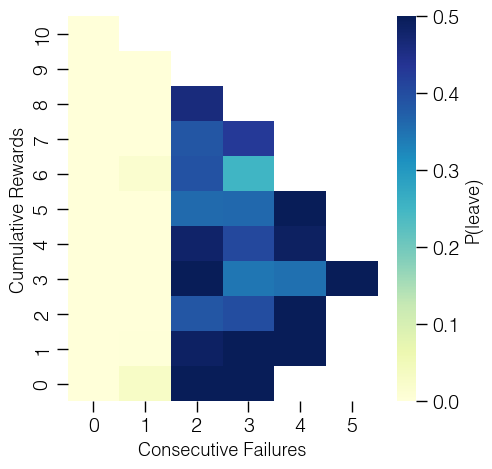

In [52]:
for df in dfs_markov_trained_v3[:1]:
    plot_stop_fraction(
        df,
        'consecutive_misses',
        'rewards_seen_in_patch',
        invert_y=True,
        # condition=lambda x: x[x['patch_type'] == 1],
        figsize=(5, 5),
        reverse=True,
        xlabel='Consecutive Failures',
        ylabel='Cumulative Rewards',
        min_n=20,
        vmin=0, vmax=0.5,
    )
None

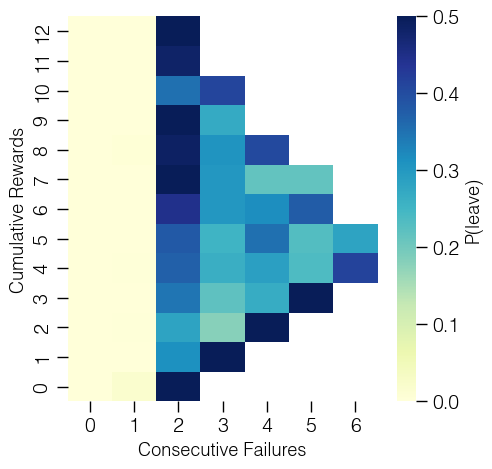

In [60]:
for df in dfs_markov_trained_v3[1:]:
    plot_stop_fraction(
        df,
        'consecutive_misses',
        'rewards_seen_in_patch',
        invert_y=True,
        condition=lambda x: x[x['patch_type'] == 1],
        figsize=(5, 5),
        reverse=True,
        xlabel='Consecutive Failures',
        ylabel='Cumulative Rewards',
        min_n=30,
        vmin=0, vmax=0.5,
    )
None

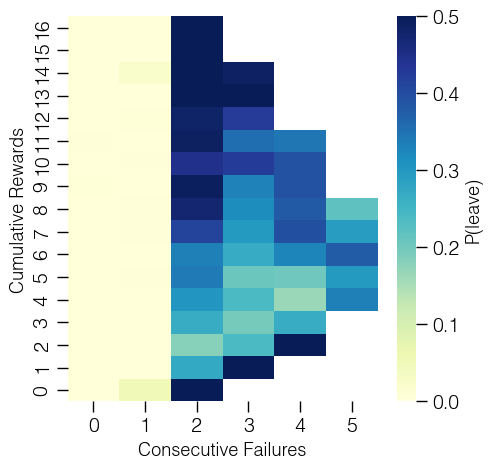

In [59]:
for df in dfs_markov_trained_v3[1:]:
    plot_stop_fraction(
        df,
        'consecutive_misses',
        'rewards_seen_in_patch',
        invert_y=True,
        condition=lambda x: x[x['patch_type'] == 2],
        figsize=(5, 5),
        reverse=True,
        xlabel='Consecutive Failures',
        ylabel='Cumulative Rewards',
        min_n=30,
        vmin=0, vmax=0.5,
    )
None